In [28]:
!pip install torch torchvision torchaudio

!pip install 'git+https://github.com/facebookresearch/detectron2.git'

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-1uq5hr1b
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-1uq5hr1b
  Resolved https://github.com/facebookresearch/detectron2.git to commit fd27788985af0f4ca800bca563acdb700bb890e2
  Preparing metadata (setup.py) ... done


In [29]:
import torch
import os
from detectron2.data.datasets import register_coco_instances
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
dataset_path = "/content/drive/MyDrive/Annotations.v1i.coco"

register_coco_instances(
    "kitchen_train_annotations",
    {},
    f"{dataset_path}/train/_annotations.coco.json",
    f"{dataset_path}/train"
)


In [40]:
cfg = get_cfg()
cfg.merge_from_file(
    model_zoo.get_config_file(
        "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
    )
)

cfg.DATASETS.TRAIN = ("kitchen_train_annotations",)
cfg.DATASETS.TEST = ()

cfg.DATALOADER.NUM_WORKERS = 2

cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
)

cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.0001
cfg.SOLVER.MAX_ITER = 2000

cfg.SOLVER.STEPS = []

cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 4  # countertop, island_top, cupboard_top

cfg.OUTPUT_DIR = "/content/drive/MyDrive/kitchen_output"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

In [43]:
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

[02/23 05:50:35 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


[02/23 05:50:35 d2.engine.train_loop]: Starting training from iteration 0
[02/23 05:50:43 d2.utils.events]:  eta: 0:10:28  iter: 19  total_loss: 3.678  loss_cls: 1.663  loss_box_reg: 0.4396  loss_mask: 0.6912  loss_rpn_cls: 0.634  loss_rpn_loc: 0.2476    time: 0.3367  last_time: 0.4043  data_time: 0.0159  last_data_time: 0.0085   lr: 1.9981e-06  max_mem: 3498M
[02/23 05:50:53 d2.utils.events]:  eta: 0:15:13  iter: 39  total_loss: 3.973  loss_cls: 1.59  loss_box_reg: 0.3536  loss_mask: 0.6894  loss_rpn_cls: 0.9817  loss_rpn_loc: 0.2427    time: 0.4330  last_time: 0.5038  data_time: 0.0271  last_data_time: 0.0170   lr: 3.9961e-06  max_mem: 3498M
[02/23 05:51:02 d2.utils.events]:  eta: 0:15:02  iter: 59  total_loss: 3.366  loss_cls: 1.497  loss_box_reg: 0.4044  loss_mask: 0.6848  loss_rpn_cls: 0.52  loss_rpn_loc: 0.1918    time: 0.4394  last_time: 0.4303  data_time: 0.0205  last_data_time: 0.0070   lr: 5.9941e-06  max_mem: 3606M
[02/23 05:51:11 d2.utils.events]:  eta: 0:14:41  iter: 79  t

In [44]:
import os
os.makedirs("/content/drive/MyDrive/kitchen_output_an", exist_ok=True)
torch.save(trainer.model.state_dict(),
           "/content/drive/MyDrive/kitchen_output_an/model_final.pth")

In [45]:
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
import cv2
import matplotlib.pyplot as plt

cfg = get_cfg()
cfg.merge_from_file(
    model_zoo.get_config_file(
        "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
    )
)

cfg.MODEL.ROI_HEADS.NUM_CLASSES = 4 # Changed from 46 to 4
cfg.MODEL.WEIGHTS = "/content/drive/MyDrive/kitchen_output_an/model_final.pth"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # confidence threshold
cfg.MODEL.DEVICE = "cuda"  # or "cpu" if no GPU

predictor = DefaultPredictor(cfg)

[02/23 06:04:30 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/kitchen_output_an/model_final.pth ...


In [49]:
from google.colab import files
uploaded = files.upload()

Saving kit2.jpg to kit2 (1).jpg


In [50]:
import numpy as np

image_path = list(uploaded.keys())[0]
im = cv2.imread(image_path)
outputs = predictor(im)

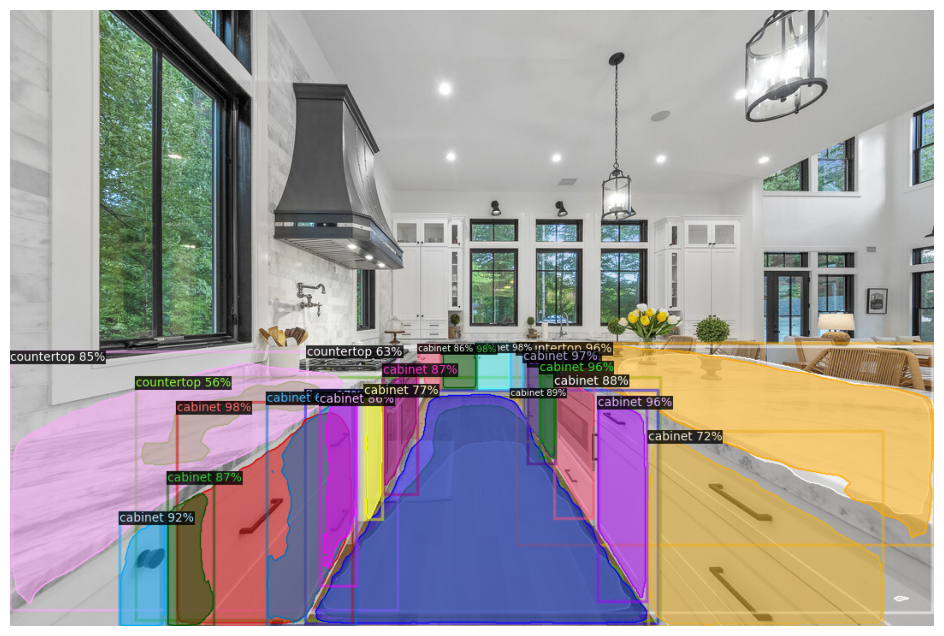

In [51]:
v = Visualizer(
    im[:, :, ::-1],
    MetadataCatalog.get("kitchen_train_annotations"),
    scale=1.0
)

out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

plt.figure(figsize=(12,8))
plt.imshow(out.get_image())
plt.axis("off")
plt.show()

# Local Countertop Mask Generation
Use the trained Detectron2 Mask R-CNN model to generate countertop masks from kitchen images.

**Prerequisites:** Place `model_final.pth` (from Google Drive) into the `countertops/` folder.

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog

# --- Configuration ---
MODEL_WEIGHTS = "countertops/model_final.pth"   # path to your trained weights
NUM_CLASSES   = 4                                 # number of classes the model was trained on
CONFIDENCE    = 0.5                               # prediction confidence threshold
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"

# Class names from your training dataset
CLASS_NAMES = ["countertop", "island_top", "cupboard_top", "other"]

# Register metadata so visualizer can show labels
MetadataCatalog.get("kitchen_infer").set(thing_classes=CLASS_NAMES)

# --- Build config & predictor ---
cfg = get_cfg()
cfg.merge_from_file(
    model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = NUM_CLASSES
cfg.MODEL.WEIGHTS = MODEL_WEIGHTS
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = CONFIDENCE
cfg.MODEL.DEVICE = DEVICE

predictor = DefaultPredictor(cfg)
print(f"Predictor ready on {DEVICE} | weights: {MODEL_WEIGHTS}")

In [ ]:
def generate_countertop_mask(image_bgr, predictor, target_classes=None):
    """
    Run the trained Detectron2 model on an image and return a
    combined binary mask for the specified class indices.

    Parameters
    ----------
    image_bgr     : np.ndarray (H, W, 3) BGR
    predictor     : DefaultPredictor
    target_classes: list[int] or None
        Class indices to include in the mask.
        Default [0, 1] = countertop + island_top.

    Returns
    -------
    mask : np.ndarray (H, W) uint8, 0 or 255
    instances : Instances object (for visualization)
    """
    if target_classes is None:
        target_classes = [0, 1]  # countertop + island_top

    outputs = predictor(image_bgr)
    instances = outputs["instances"].to("cpu")

    h, w = image_bgr.shape[:2]
    combined_mask = np.zeros((h, w), dtype=np.uint8)

    pred_classes = instances.pred_classes.numpy()
    pred_masks = instances.pred_masks.numpy()  # (N, H, W) bool

    for i, cls_id in enumerate(pred_classes):
        if cls_id in target_classes:
            combined_mask[pred_masks[i]] = 255

    return combined_mask, instances


def clean_countertop_mask(mask, kernel_size=5, close_iter=2):
    """Morphological cleaning: close holes, smooth edges."""
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    cleaned = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=close_iter)
    return cleaned


print("Helper functions defined.")

In [ ]:
# --- Process all kitchen images ---
kitchen_dir = Path("rooms/kitchens")
output_dir  = Path("countertops")
output_dir.mkdir(parents=True, exist_ok=True)

image_paths = sorted(kitchen_dir.glob("*.jpg")) + sorted(kitchen_dir.glob("*.jpeg")) + sorted(kitchen_dir.glob("*.png"))
print(f"Found {len(image_paths)} images")

for img_path in image_paths:
    print(f"\n{'='*50}")
    print(f"Processing: {img_path.name}")

    # Load image
    image_bgr = cv2.imread(str(img_path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # Generate mask (classes 0=countertop, 1=island_top)
    mask, instances = generate_countertop_mask(image_bgr, predictor, target_classes=[0, 1])
    cleaned_mask = clean_countertop_mask(mask)

    # Save mask
    mask_save_path = output_dir / f"{img_path.stem}_countertop_mask.png"
    cv2.imwrite(str(mask_save_path), cleaned_mask)

    # --- Visualization ---
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    # Original
    axes[0].imshow(image_rgb)
    axes[0].set_title("Original")
    axes[0].axis("off")

    # Detectron2 predictions (all classes)
    v = Visualizer(image_rgb, MetadataCatalog.get("kitchen_infer"), scale=1.0,
                   instance_mode=ColorMode.IMAGE_BW)
    vis_out = v.draw_instance_predictions(instances)
    axes[1].imshow(vis_out.get_image())
    axes[1].set_title(f"Predictions ({len(instances)} instances)")
    axes[1].axis("off")

    # Binary mask
    axes[2].imshow(cleaned_mask, cmap="gray")
    axes[2].set_title(f"Countertop Mask ({np.count_nonzero(cleaned_mask)} px)")
    axes[2].axis("off")

    # Overlay
    overlay = image_rgb.copy()
    overlay[cleaned_mask > 0] = [255, 50, 50]
    blended = cv2.addWeighted(image_rgb, 0.6, overlay, 0.4, 0)
    axes[3].imshow(blended)
    axes[3].set_title("Mask Overlay")
    axes[3].axis("off")

    plt.suptitle(img_path.name, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"  Saved: {mask_save_path}")

print(f"\nDone! All masks saved to '{output_dir}'")

In [ ]:
# --- Single image: inspect all predictions in detail ---
img_path = Path("rooms/kitchens/kit1.jpg")  # <-- change as needed
image_bgr = cv2.imread(str(img_path))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

outputs = predictor(image_bgr)
instances = outputs["instances"].to("cpu")

print(f"Image: {img_path.name}")
print(f"Detected {len(instances)} instances\n")

# Show each detected instance
for i in range(len(instances)):
    cls = instances.pred_classes[i].item()
    score = instances.scores[i].item()
    label = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else f"class_{cls}"
    print(f"  Instance {i}: {label} (class {cls}) — confidence {score:.3f}")

    # Individual mask preview
    single_mask = instances.pred_masks[i].numpy().astype(np.uint8) * 255

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(single_mask, cmap="gray")
    axes[0].set_title(f"Mask: {label} ({score:.2f})")
    axes[0].axis("off")

    overlay = image_rgb.copy()
    overlay[single_mask > 0] = [0, 255, 0]
    blended = cv2.addWeighted(image_rgb, 0.6, overlay, 0.4, 0)
    axes[1].imshow(blended)
    axes[1].set_title("Overlay")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()